# Notebook 4 – Evaluasi & Analisis Model

**Tujuan:** Evaluasi final ketiga model (182 fitur: 164 kanonik + 18 DDS) pada
test set — confusion matrix, feature importance, SHAP, dan kesimpulan akhir.

**Output yang dihasilkan:**
- `outputs/results/nb04_*.png`
- `outputs/results/test_comparison.csv`

**Tahap penelitian:** Tahap 6 (Evaluasi)

> **Prasyarat:** Model harus sudah tersimpan di `outputs/models/` (dari `03_modeling.ipynb` di folder ini).


---
## 0. Setup

In [1]:
import sys
import pickle
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT       = ROOT / 'outputs' / 'results'
MODEL_DIR = ROOT / 'outputs' / 'models'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
MODEL_COLORS = ['#4472C4', '#ED7D31', '#70AD47']
print('Setup selesai.')


Setup selesai.


---
## 1. Load Model & Dataset

In [2]:
from src.preprocessing import load_splits

df_train, df_val, df_test, feature_cols, le = load_splits(ROOT / 'data' / 'processed')

X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test['label'].values
X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train['label'].values

class_names = list(le.classes_)
n_classes   = len(class_names)

print(f'Test set  : {X_test.shape}')
print(f'Kelas     : {n_classes}')
print(f'Fitur     : {len(feature_cols)}  (164 kanonik + 18 DDS)')

trained_models = []
model_names    = ['RandomForest', 'XGBoost', 'LightGBM']
for name in model_names:
    path = MODEL_DIR / f'{name.lower()}.pkl'
    assert path.exists(), f'Model tidak ditemukan: {path}. Jalankan 03_modeling.ipynb (folder ini) terlebih dahulu.'
    with open(path, 'rb') as f:
        trained_models.append(pickle.load(f))
    print(f'  Loaded: {name}')


Test set  : (7461, 182)
Kelas     : 36
Fitur     : 182  (164 kanonik + 18 DDS)
  Loaded: RandomForest
  Loaded: XGBoost
  Loaded: LightGBM


---
## 2. Evaluasi Final – Test Set

In [3]:
from src.evaluation import evaluate, print_summary, compare_models, save_results

test_results = []
predictions  = {}
probabilities = {}

for model in trained_models:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    res = evaluate(y_test, y_pred, y_proba, le, model_name=model.name)
    test_results.append(res)
    predictions[model.name]   = y_pred
    probabilities[model.name] = y_proba
    save_results(res, OUT / f'nb04_{model.name.lower()}_test.json')
    print_summary(res)



  RandomForest
  Accuracy          : 0.4684
  Precision (macro) : 0.3129
  Recall (macro)    : 0.3615
  F1 (macro)        : 0.3251
  F1 (weighted)     : 0.4854
  Top-3 Accuracy    : 0.7715
  Top-5 Accuracy    : 0.8737

  XGBoost
  Accuracy          : 0.5611
  Precision (macro) : 0.4615
  Recall (macro)    : 0.3145
  F1 (macro)        : 0.3416
  F1 (weighted)     : 0.5322
  Top-3 Accuracy    : 0.8175
  Top-5 Accuracy    : 0.8984

  LightGBM
  Accuracy          : 0.5639
  Precision (macro) : 0.4543
  Recall (macro)    : 0.3915
  F1 (macro)        : 0.4101
  F1 (weighted)     : 0.5567
  Top-3 Accuracy    : 0.8208
  Top-5 Accuracy    : 0.8972


In [4]:
test_df = compare_models(test_results)
test_df.to_csv(OUT / 'test_comparison.csv')

print('=== Tabel Perbandingan (182 fitur) - Test Set ===')
display(test_df.style
    .format('{:.4f}')
    .highlight_max(color='#C8E6C9', axis=0)
    .highlight_min(color='#FFCDD2', axis=0)
    .set_caption('Hijau = terbaik . Merah = terburuk per metrik'))


=== Tabel Perbandingan (182 fitur) - Test Set ===


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
model,,,,,,,
RandomForest,0.4684,0.3129,0.3615,0.3251,0.4854,0.7715,0.8737
XGBoost,0.5611,0.4615,0.3145,0.3416,0.5322,0.8175,0.8984
LightGBM,0.5639,0.4543,0.3915,0.4101,0.5567,0.8208,0.8972


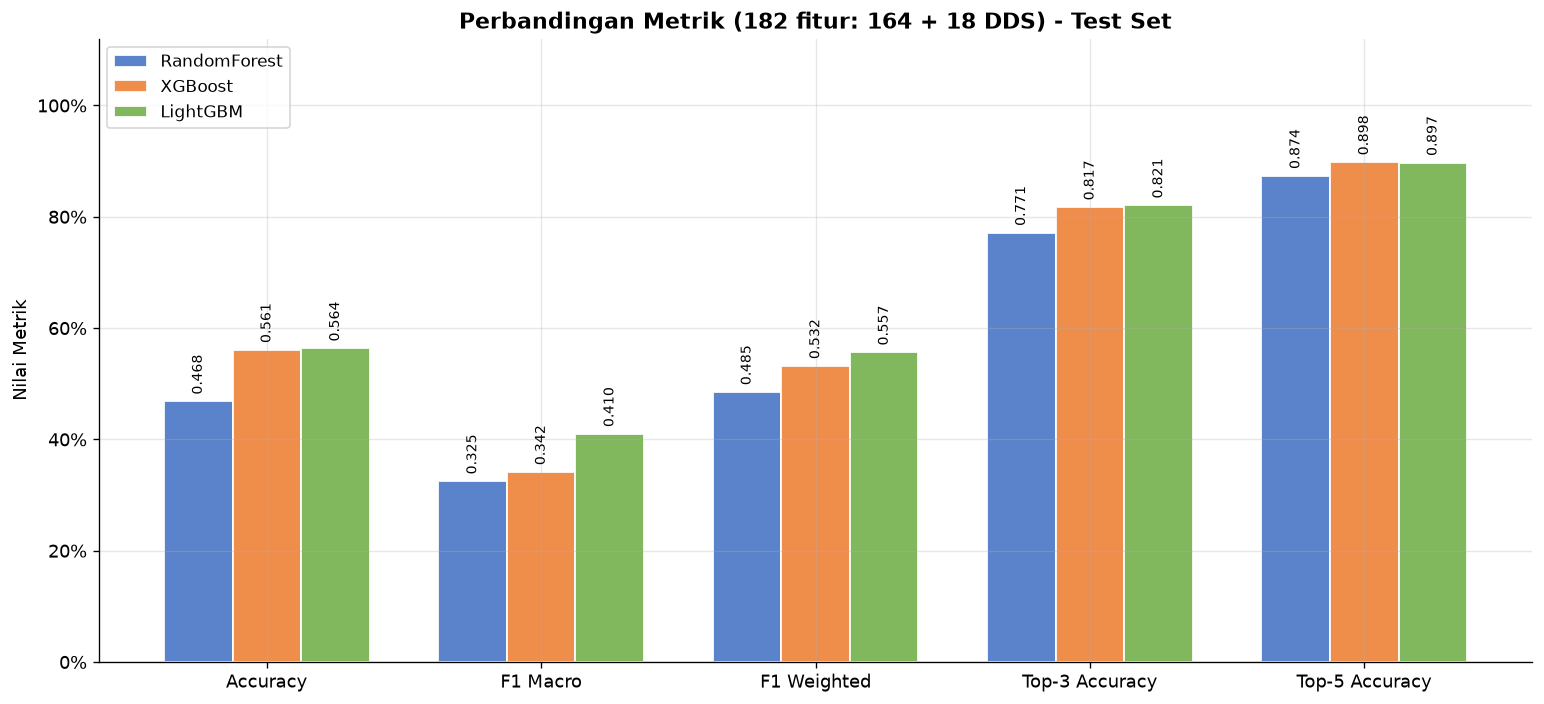

In [5]:
metrics_plot  = ['accuracy', 'f1_macro', 'f1_weighted', 'top_3_accuracy', 'top_5_accuracy']
metrics_label = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Top-3 Accuracy', 'Top-5 Accuracy']

x = np.arange(len(metrics_plot))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (res, color) in enumerate(zip(test_results, MODEL_COLORS)):
    vals = [res.get(m, 0) for m in metrics_plot]
    bars = ax.bar(x + i * w, vals, w, label=res['model'], color=color,
                  alpha=0.88, edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='%.3f', fontsize=8.5, rotation=90, padding=4)

ax.set_xticks(x + w)
ax.set_xticklabels(metrics_label, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Perbandingan Metrik (182 fitur: 164 + 18 DDS) - Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Nilai Metrik')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUT / 'nb04_model_comparison.png', bbox_inches='tight')
plt.show()


---
## 3. Confusion Matrix

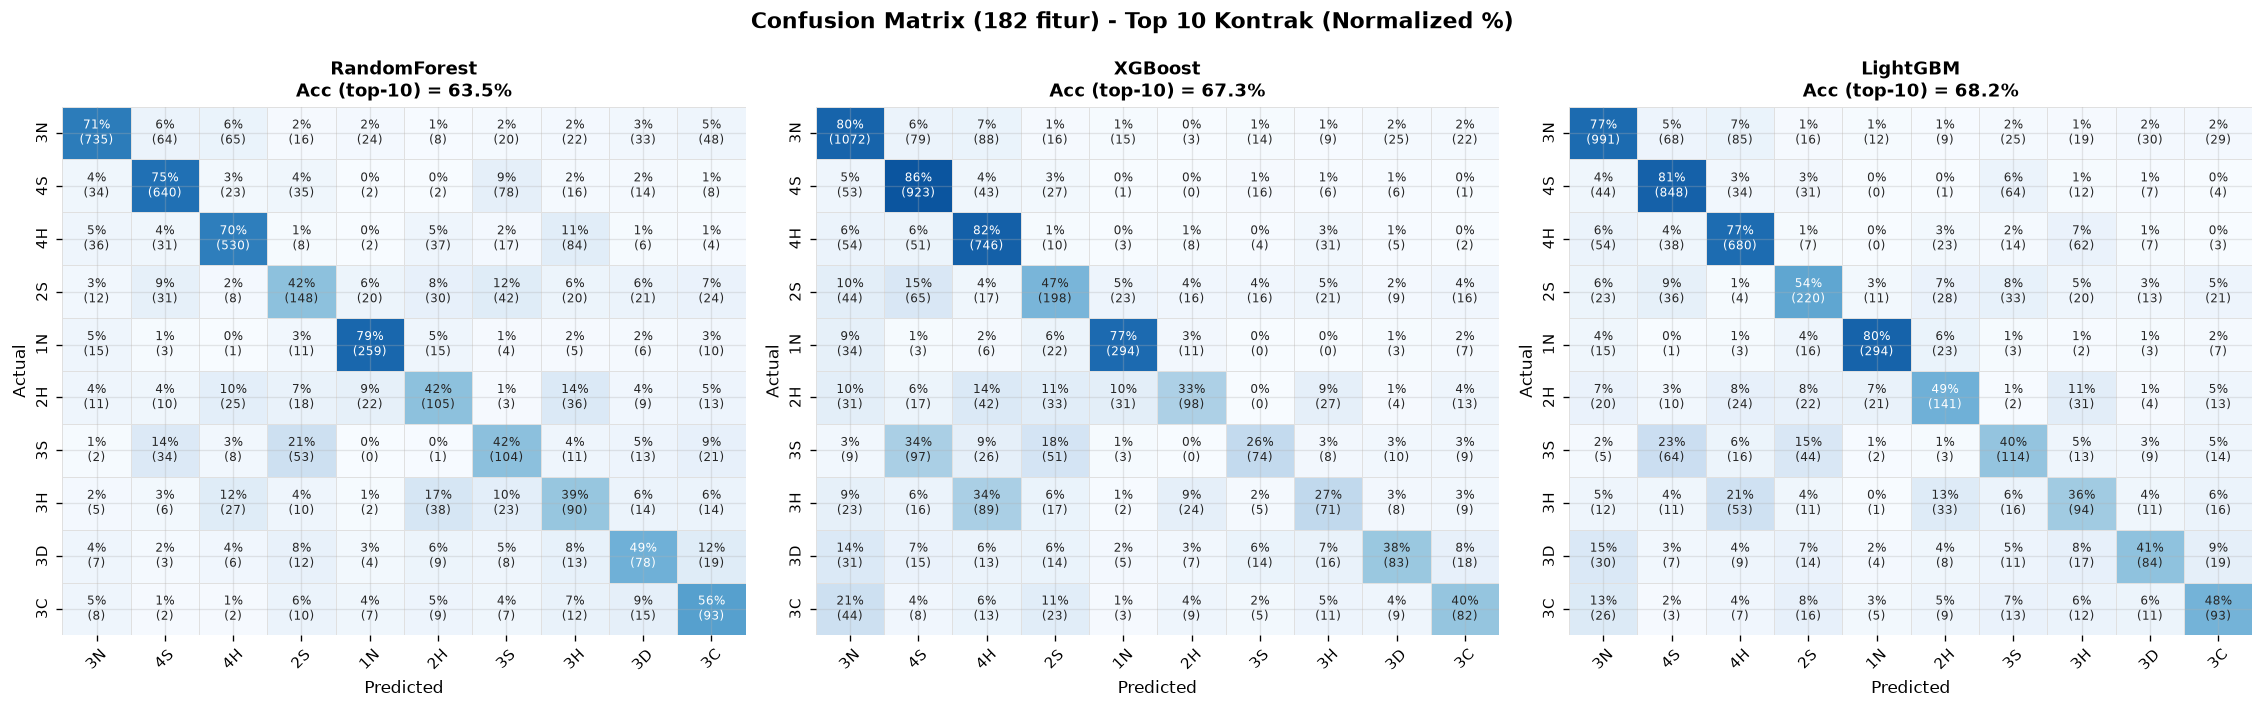

In [6]:
from sklearn.metrics import confusion_matrix

test_label_cnt = Counter(le.inverse_transform(y_test))
top10          = [c for c, _ in test_label_cnt.most_common(10)]
top10_idx      = [class_names.index(c) for c in top10]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

for ax, model, color in zip(axes, trained_models, MODEL_COLORS):
    y_pred = predictions[model.name]
    mask   = np.isin(y_test, top10_idx)
    mat    = confusion_matrix(y_test[mask], y_pred[mask], labels=top10_idx)
    mat_pct = mat.astype(float) / mat.sum(axis=1, keepdims=True) * 100

    annot = np.array([
        [f'{mat_pct[r,c]:.0f}%\n({mat[r,c]})' for c in range(len(top10))]
        for r in range(len(top10))
    ])

    sns.heatmap(
        mat_pct, annot=annot, fmt='', cmap='Blues',
        xticklabels=top10, yticklabels=top10,
        ax=ax, cbar=False,
        linewidths=0.4, linecolor='#E0E0E0',
        vmin=0, vmax=100,
        annot_kws={'size': 7},
    )
    acc_top10 = mat.diagonal().sum() / mat.sum()
    ax.set_title(f'{model.name}\nAcc (top-10) = {acc_top10:.1%}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Confusion Matrix (182 fitur) - Top 10 Kontrak (Normalized %)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb04_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 4. F1 Score per Kelas

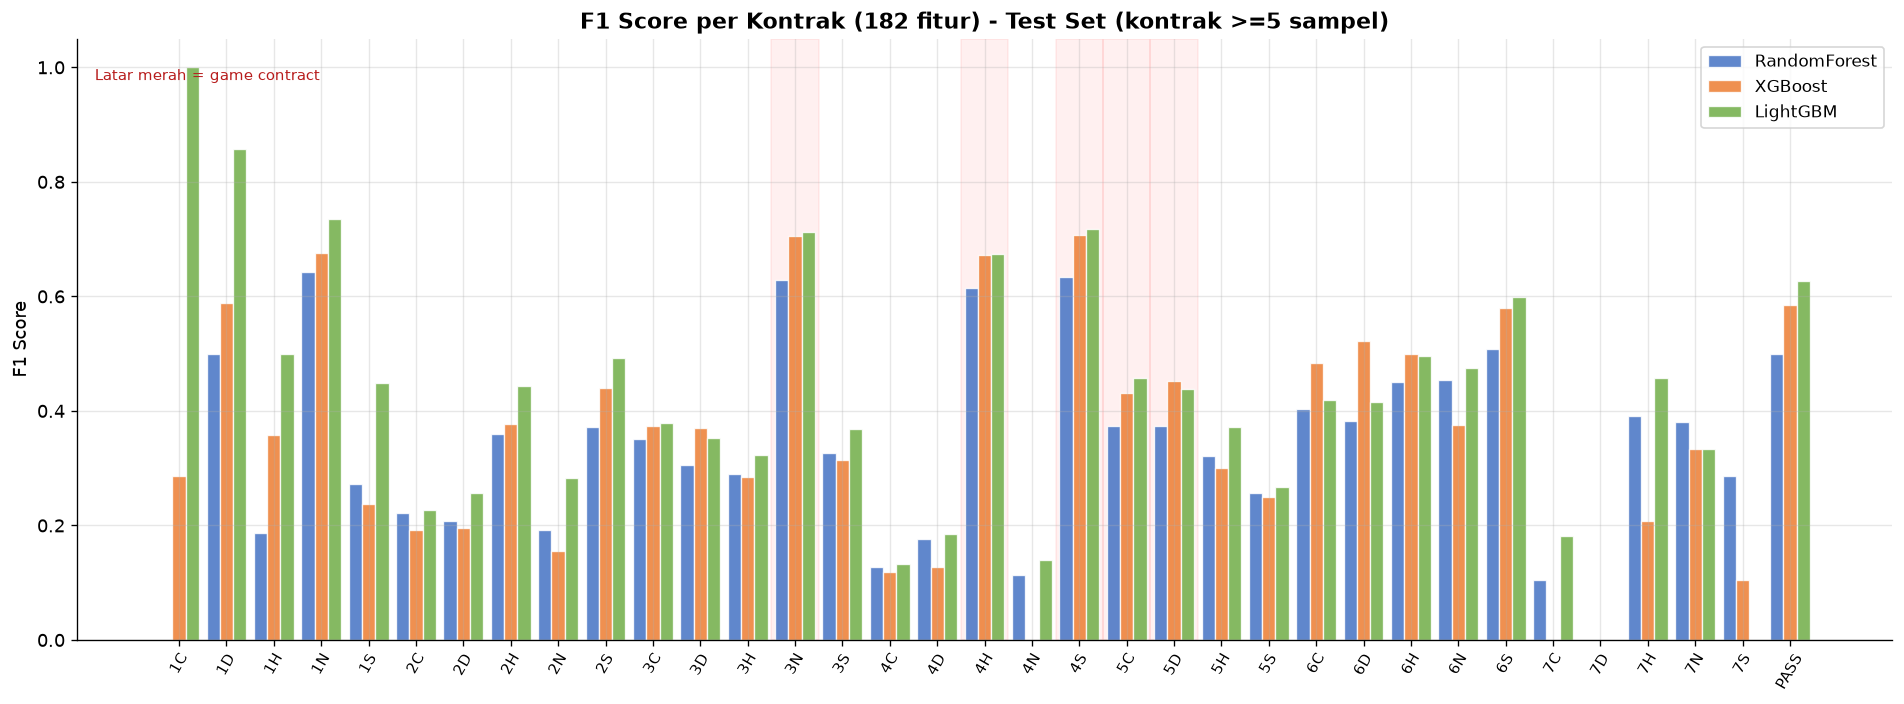

In [7]:
from sklearn.metrics import f1_score

all_labels   = list(range(n_classes))
min_samples  = 5

test_cnt     = Counter(y_test)
show_idx     = [i for i in all_labels if test_cnt.get(i, 0) >= min_samples]
show_names   = [class_names[i] for i in show_idx]

f1_data = {}
for model in trained_models:
    y_pred = predictions[model.name]
    f1s    = f1_score(y_test, y_pred, labels=all_labels, average=None, zero_division=0)
    f1_data[model.name] = [f1s[i] for i in show_idx]

x = np.arange(len(show_names))
w = 0.28

fig, ax = plt.subplots(figsize=(16, 6))
for i, (model_name, f1_vals) in enumerate(f1_data.items()):
    ax.bar(x + (i - 1) * w, f1_vals, w,
           label=model_name, color=MODEL_COLORS[i],
           alpha=0.85, edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(show_names, rotation=60, fontsize=9)
ax.set_title(f'F1 Score per Kontrak (182 fitur) - Test Set (kontrak >={min_samples} sampel)', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)

game_set = {'3N', '4S', '4H', '5D', '5C'}
for idx, name in enumerate(show_names):
    if name in game_set:
        ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.06, color='red', zorder=0)

ax.text(0.01, 0.95, 'Latar merah = game contract', transform=ax.transAxes,
        fontsize=9, color='#B71C1C', va='top')

plt.tight_layout()
plt.savefig(OUT / 'nb04_f1_per_class.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 5. Feature Importance (dengan kategori DDS)

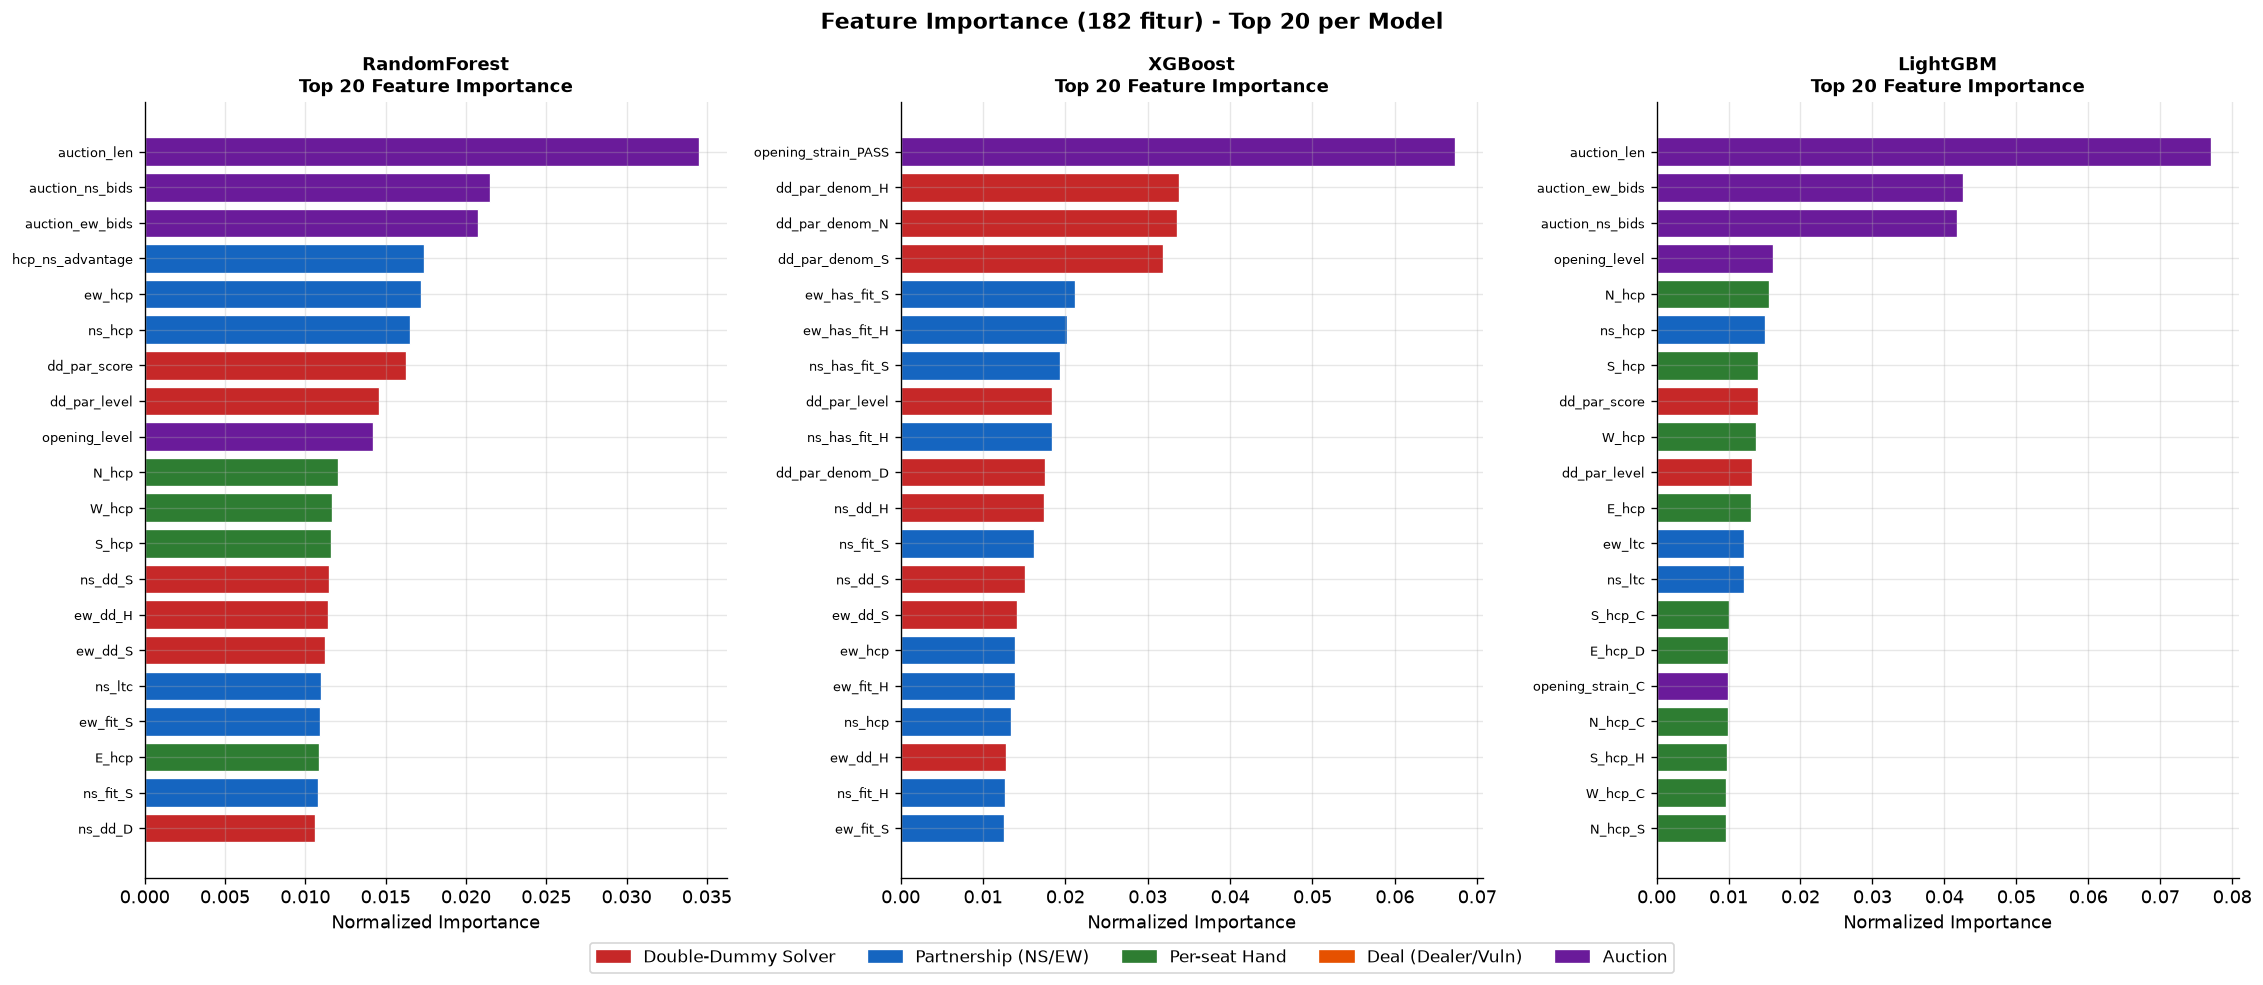

In [8]:
N_TOP = 20

def feat_group_color(name):
    if name.startswith(('ns_dd', 'ew_dd', 'dd_par')):
        return '#C62828'  # merah: Double-Dummy Solver
    if name.startswith(('ns_', 'ew_', 'hcp_ns')):
        return '#1565C0'  # biru: partnership
    if len(name) >= 2 and name[0] in 'NESW' and name[1] == '_':
        return '#2E7D32'  # hijau: per-seat hand
    if name.startswith(('dealer_', 'vuln_')):
        return '#E65100'  # oranye: deal
    return '#6A1B9A'      # ungu: auction

fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, model, color in zip(axes, trained_models, MODEL_COLORS):
    imp = model.feature_importances()
    imp = imp / imp.sum()
    top_idx   = np.argsort(imp)[::-1][:N_TOP]
    top_names = [feature_cols[i] for i in top_idx]
    top_vals  = imp[top_idx]
    bar_colors = [feat_group_color(n) for n in top_names]

    ax.barh(
        range(N_TOP), top_vals[::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.8,
    )
    ax.set_yticks(range(N_TOP))
    ax.set_yticklabels(list(reversed(top_names)), fontsize=8)
    ax.set_title(f'{model.name}\nTop {N_TOP} Feature Importance', fontweight='bold', fontsize=11)
    ax.set_xlabel('Normalized Importance')

legend_el = [
    mpatches.Patch(color='#C62828', label='Double-Dummy Solver'),
    mpatches.Patch(color='#1565C0', label='Partnership (NS/EW)'),
    mpatches.Patch(color='#2E7D32', label='Per-seat Hand'),
    mpatches.Patch(color='#E65100', label='Deal (Dealer/Vuln)'),
    mpatches.Patch(color='#6A1B9A', label='Auction'),
]
fig.legend(handles=legend_el, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle(f'Feature Importance (182 fitur) - Top {N_TOP} per Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb04_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()


In [9]:
# Berapa banyak fitur DDS yang masuk top-20 tiap model?
for model in trained_models:
    imp = model.feature_importances()
    imp = imp / imp.sum()
    top_idx = np.argsort(imp)[::-1][:N_TOP]
    top_names = [feature_cols[i] for i in top_idx]
    n_dds = sum(1 for n in top_names if n.startswith(('ns_dd', 'ew_dd', 'dd_par')))
    print(f'{model.name:<15}: {n_dds}/{N_TOP} fitur top-20 adalah fitur DDS')

# Fitur yang konsisten penting di semua model (consensus)
all_top20 = {}
for model in trained_models:
    imp = model.feature_importances()
    imp = imp / imp.sum()
    top_idx = set(np.argsort(imp)[::-1][:20])
    all_top20[model.name] = top_idx

consensus = all_top20['RandomForest'] & all_top20['XGBoost'] & all_top20['LightGBM']
print(f'\nFitur yang masuk top-20 di SEMUA model ({len(consensus)} fitur):')
print()
avg_imp = {}
for idx in consensus:
    vals = [model.feature_importances()[idx] / model.feature_importances().sum()
            for model in trained_models]
    avg_imp[idx] = np.mean(vals)

for rank, (idx, avg) in enumerate(sorted(avg_imp.items(), key=lambda x: -x[1]), 1):
    name = feature_cols[idx]
    group = ('Double-Dummy Solver' if name.startswith(('ns_dd','ew_dd','dd_par')) else
             'Partnership' if name.startswith(('ns_','ew_','hcp_ns')) else
             'Per-seat Hand' if (name[0] in 'NESW' and '_' in name) else
             'Deal' if name.startswith(('dealer_','vuln_')) else 'Auction')
    print(f'  {rank:2d}. {name:<35}  avg={avg:.4f}  [{group}]')


RandomForest   : 6/20 fitur top-20 adalah fitur DDS
XGBoost        : 9/20 fitur top-20 adalah fitur DDS
LightGBM       : 2/20 fitur top-20 adalah fitur DDS

Fitur yang masuk top-20 di SEMUA model (2 fitur):

   1. dd_par_level                         avg=0.0154  [Double-Dummy Solver]
   2. ns_hcp                               avg=0.0150  [Partnership]


---
## 6. SHAP Analysis

In [10]:
try:
    import shap
    SHAP_OK = True
    print(f'SHAP {shap.__version__} tersedia.')
except ImportError:
    SHAP_OK = False
    print('SHAP tidak tersedia. Install: pip install shap')
    print('Melewati seksi SHAP.')


SHAP 0.52.0 tersedia.


In [11]:
if SHAP_OK:
    xgb_model = next(m for m in trained_models if m.name == 'XGBoost')
    X_shap    = X_test[:300]

    print('Menghitung SHAP values untuk XGBoost (300 sampel)...')
    explainer   = shap.TreeExplainer(xgb_model.clf)
    shap_values = explainer.shap_values(X_shap)
    print(f'Selesai. Shape: {np.array(shap_values).shape}')


Menghitung SHAP values untuk XGBoost (300 sampel)...
Selesai. Shape: (300, 182, 36)


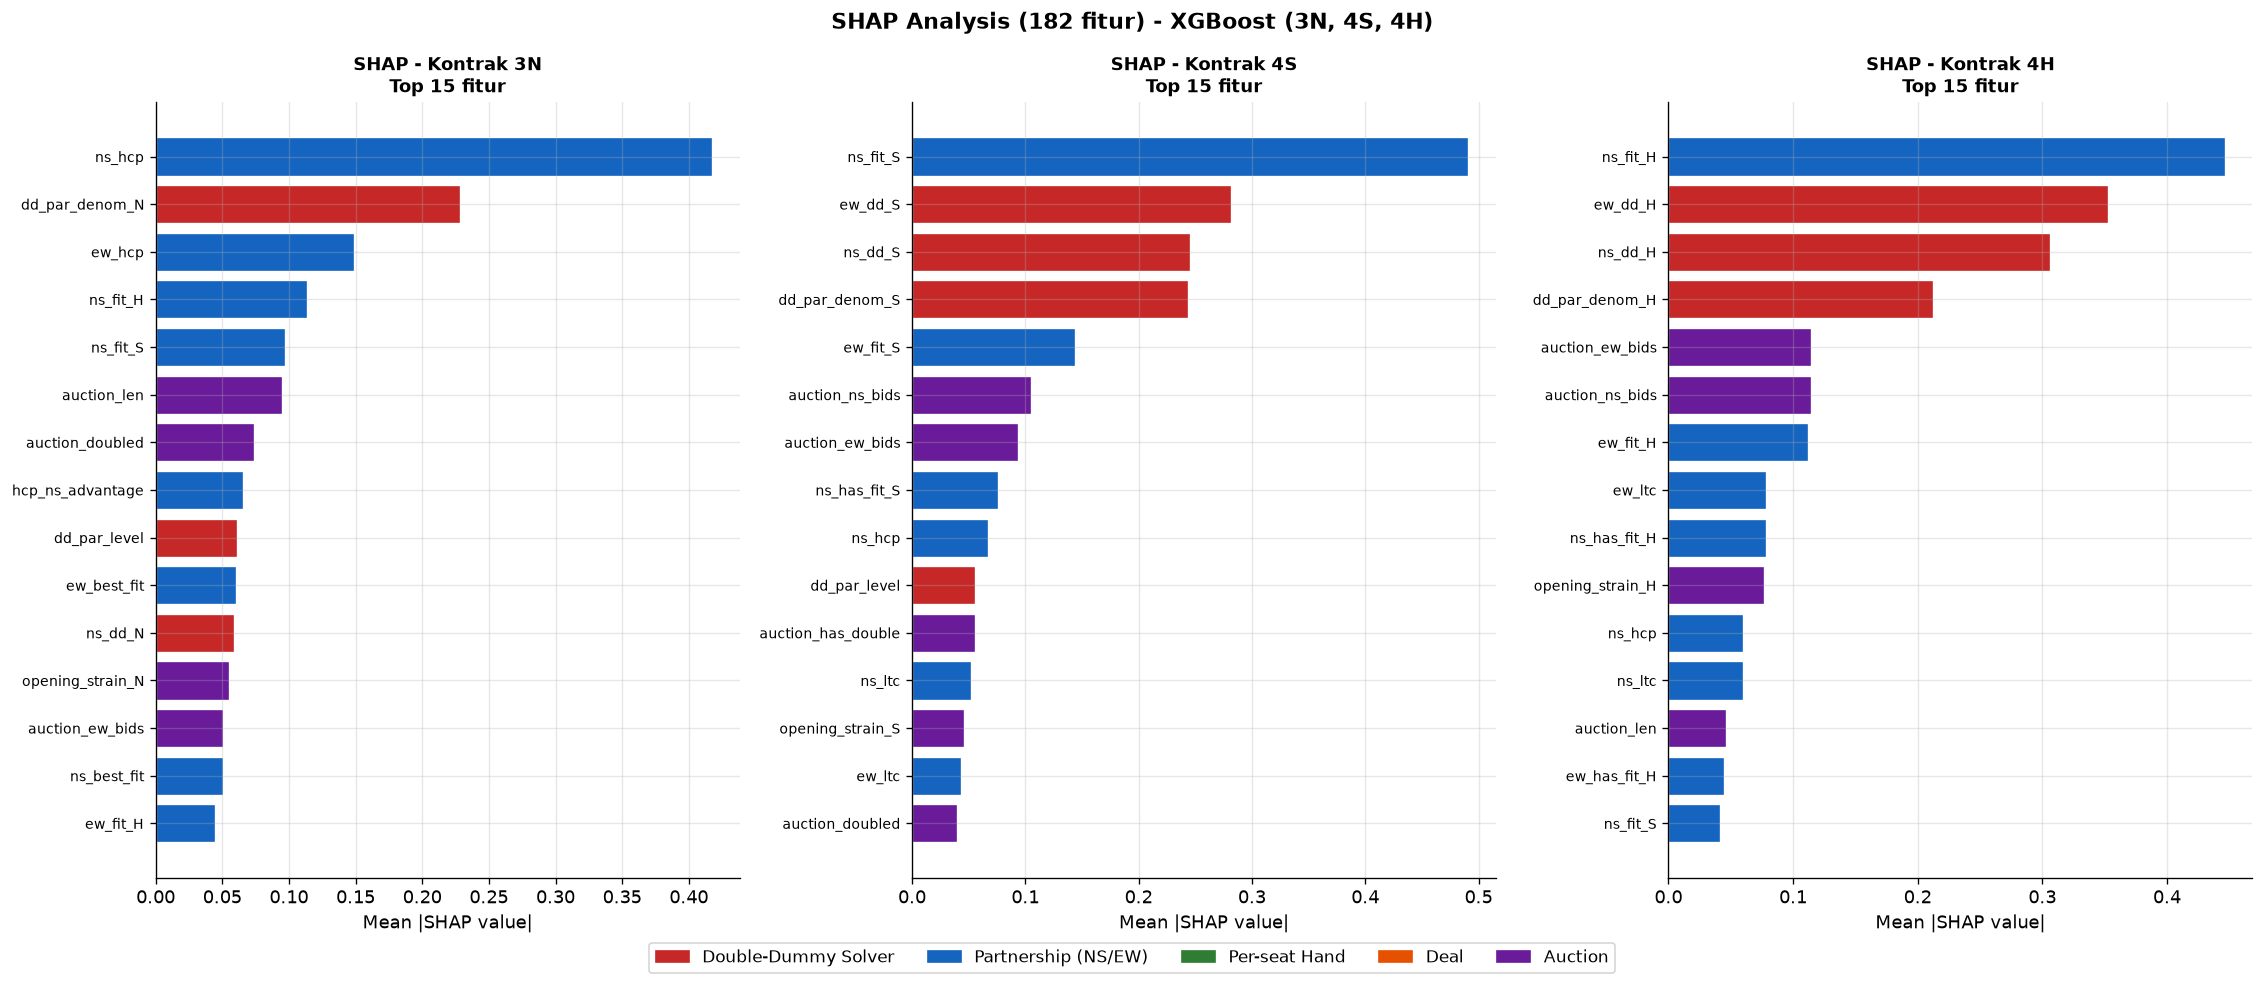

In [12]:
if SHAP_OK:
    def get_sv(sv, cls_idx):
        if isinstance(sv, list):
            return np.array(sv[cls_idx])
        return np.array(sv)[:, :, cls_idx]

    target_contracts = ['3N', '4S', '4H']
    fig, axes = plt.subplots(1, 3, figsize=(19, 8))

    for ax, contract in zip(axes, target_contracts):
        if contract not in class_names:
            ax.set_visible(False)
            continue

        cls_idx  = class_names.index(contract)
        sv       = get_sv(shap_values, cls_idx)
        mean_abs = np.abs(sv).mean(axis=0)
        top15    = np.argsort(mean_abs)[::-1][:15]
        names15  = [feature_cols[i] for i in top15]
        vals15   = mean_abs[top15]
        bar_cols = [feat_group_color(n) for n in names15]

        ax.barh(range(15), vals15[::-1], color=bar_cols[::-1],
                edgecolor='white', linewidth=0.8)
        ax.set_yticks(range(15))
        ax.set_yticklabels(list(reversed(names15)), fontsize=8.5)
        ax.set_title(f'SHAP - Kontrak {contract}\nTop 15 fitur', fontweight='bold', fontsize=11)
        ax.set_xlabel('Mean |SHAP value|')

    legend_el = [
        mpatches.Patch(color='#C62828', label='Double-Dummy Solver'),
        mpatches.Patch(color='#1565C0', label='Partnership (NS/EW)'),
        mpatches.Patch(color='#2E7D32', label='Per-seat Hand'),
        mpatches.Patch(color='#E65100', label='Deal'),
        mpatches.Patch(color='#6A1B9A', label='Auction'),
    ]
    fig.legend(handles=legend_el, loc='lower center', ncol=5, fontsize=10,
               bbox_to_anchor=(0.5, -0.03))

    plt.suptitle('SHAP Analysis (182 fitur) - XGBoost (3N, 4S, 4H)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT / 'nb04_shap_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()


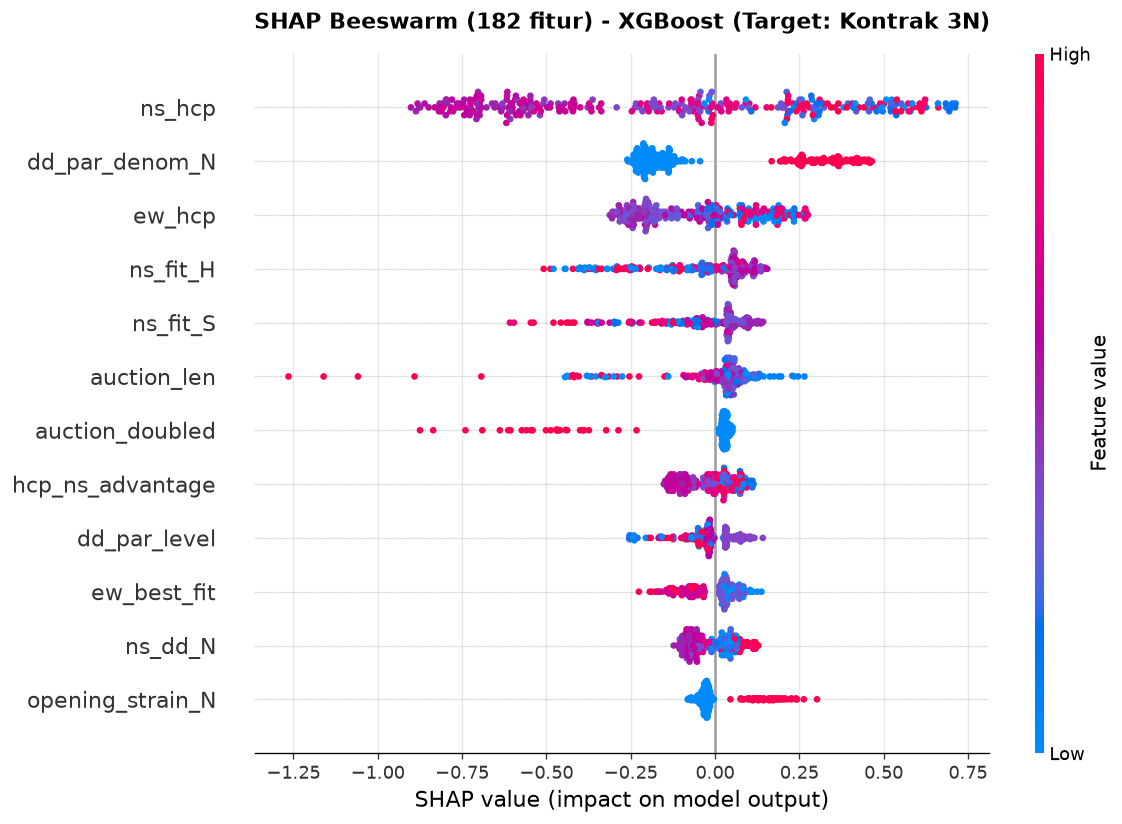

In [13]:
if SHAP_OK:
    cls_idx  = class_names.index('3N')
    sv_3N    = get_sv(shap_values, cls_idx)
    mean_abs = np.abs(sv_3N).mean(axis=0)
    top12    = np.argsort(mean_abs)[::-1][:12]

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        sv_3N[:, top12],
        X_shap[:, top12],
        feature_names=[feature_cols[i] for i in top12],
        show=False, plot_size=None,
    )
    plt.title('SHAP Beeswarm (182 fitur) - XGBoost (Target: Kontrak 3N)',
              fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(OUT / 'nb04_shap_beeswarm_3N.png', bbox_inches='tight', dpi=150)
    plt.show()


---
## 7. Radar Chart & Kesimpulan Akhir

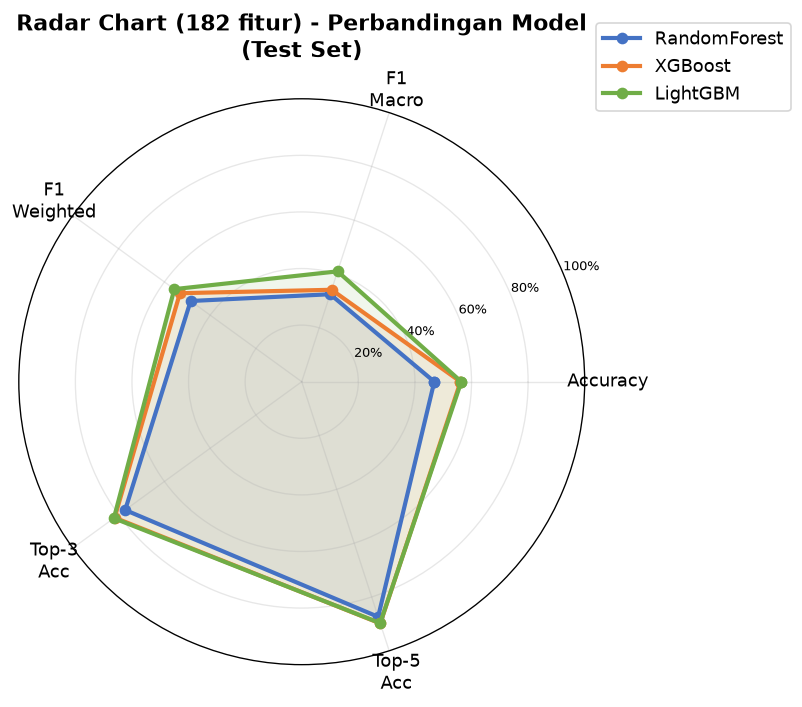

In [14]:
metrics_radar = ['accuracy', 'f1_macro', 'f1_weighted', 'top_3_accuracy', 'top_5_accuracy']
labels_radar  = ['Accuracy', 'F1\nMacro', 'F1\nWeighted', 'Top-3\nAcc', 'Top-5\nAcc']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

for res, color in zip(test_results, MODEL_COLORS):
    vals = [res.get(m, 0) for m in metrics_radar] + [res.get(metrics_radar[0], 0)]
    ax.plot(angles, vals, 'o-', lw=2.5, label=res['model'], color=color)
    ax.fill(angles, vals, alpha=0.10, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax.set_title('Radar Chart (182 fitur) - Perbandingan Model\n(Test Set)', fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig(OUT / 'nb04_radar.png', bbox_inches='tight', dpi=150)
plt.show()


In [15]:

# -- Kesimpulan Penelitian (otomatis dari test_results) ----------------
import json

n_total    = len(df_train) + len(df_val) + len(df_test)
n_classes  = len(le.classes_)
n_features = len(feature_cols)

best_acc  = max(test_results, key=lambda r: r['accuracy'])
best_f1m  = max(test_results, key=lambda r: r['f1_macro'])
best_f1w  = max(test_results, key=lambda r: r['f1_weighted'])
best_top3 = max(test_results, key=lambda r: r.get('top_3_accuracy', 0))

print('=' * 62)
print('  KESIMPULAN PENELITIAN (182 fitur: 164 kanonik + 18 DDS)')
print('=' * 62)
print(f'\nDataset:')
print(f'  Total board (setelah deduplication) : {n_total:,}')
print(f'  Train / Val / Test                  : {len(df_train):,} / {len(df_val):,} / {len(df_test):,}')
print(f'  Kelas kontrak                        : {n_classes} (PASS + {n_classes-1} kontrak)')
print(f'  Fitur numerik/biner                  : {n_features} (164 kanonik + 18 DDS)')
print()
print('Hasil Test Set:')
print(f'  {"Model":<15} {"Accuracy":>10} {"F1 Macro":>10} {"F1 Weighted":>12} {"Top-3":>8} {"Top-5":>8}')
print('  ' + '-' * 60)
for res in test_results:
    print(f'  {res["model"]:<15}'
          f' {res["accuracy"]:>10.4f}'
          f' {res["f1_macro"]:>10.4f}'
          f' {res["f1_weighted"]:>12.4f}'
          f' {res.get("top_3_accuracy", 0):>8.4f}'
          f' {res.get("top_5_accuracy", 0):>8.4f}')
print()
print('Pemenang per metrik:')
print(f'  Accuracy terbaik   : {best_acc["model"]:<15} ({best_acc["accuracy"]:.4f})')
print(f'  F1 Macro terbaik   : {best_f1m["model"]:<15} ({best_f1m["f1_macro"]:.4f})')
print(f'  F1 Weighted terbaik: {best_f1w["model"]:<15} ({best_f1w["f1_weighted"]:.4f})')
print(f'  Top-3 Acc terbaik  : {best_top3["model"]:<15} ({best_top3.get("top_3_accuracy",0):.4f})')
print()

from collections import Counter as _C
test_label_names = le.inverse_transform(y_test)
top3_class = _C(test_label_names).most_common(3)
dom_cls, dom_cnt = top3_class[0]
dom_pct = dom_cnt / len(y_test) * 100
print('Temuan Utama:')
print(f'  Kelas dominan      : {dom_cls} ({dom_pct:.1f}% test set) -> class imbalance utama')
print(f'  Top-3 Accuracy     : ~{best_top3.get("top_3_accuracy",0):.0%} -> kontrak benar masuk 3 kandidat teratas')
print(f'  F1 Macro rendah (~{best_f1m["f1_macro"]:.2f}) karena class imbalance ekstrem')
print()
print(f'Output tersimpan di: {OUT}')

# Bandingkan dengan pipeline 164-fitur kanonik (jika tersedia)
canonical_test_csv = ROOT / 'outputs' / 'results' / 'test_comparison.csv'
if canonical_test_csv.exists():
    canon_df = pd.read_csv(canonical_test_csv, index_col=0)
    print()
    print('=' * 62)
    print('  PERBANDINGAN: 164 fitur (kanonik) vs 182 fitur (+ DDS)')
    print('=' * 62)
    for model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
        if model_name in canon_df.index:
            canon_acc = canon_df.loc[model_name, 'accuracy']
            canon_f1w = canon_df.loc[model_name, 'f1_weighted']
            dds_row = next(r for r in test_results if r['model'] == model_name)
            print(f'  {model_name:<15} acc: {canon_acc:.4f} -> {dds_row["accuracy"]:.4f}  '
                  f'({(dds_row["accuracy"]-canon_acc)*100:+.2f}pp)   '
                  f'F1w: {canon_f1w:.4f} -> {dds_row["f1_weighted"]:.4f}  '
                  f'({(dds_row["f1_weighted"]-canon_f1w)*100:+.2f}pp)')

summary = {
    'dataset': {
        'n_total': n_total,
        'n_train': len(df_train),
        'n_val':   len(df_val),
        'n_test':  len(df_test),
        'n_classes': n_classes,
        'n_features': n_features,
    },
    'test_results': [
        {k: v for k, v in r.items()
         if k not in ('per_class_report', 'confusion_matrix', 'class_names')}
        for r in test_results
    ],
    'best': {
        'accuracy':    best_acc['model'],
        'f1_macro':    best_f1m['model'],
        'f1_weighted': best_f1w['model'],
    },
}
summary_path = OUT / 'nb04_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print(f'\nRingkasan JSON disimpan: {summary_path.name}')


  KESIMPULAN PENELITIAN (182 fitur: 164 kanonik + 18 DDS)

Dataset:
  Total board (setelah deduplication) : 49,755
  Train / Val / Test                  : 34,832 / 7,462 / 7,461
  Kelas kontrak                        : 36 (PASS + 35 kontrak)
  Fitur numerik/biner                  : 182 (164 kanonik + 18 DDS)

Hasil Test Set:
  Model             Accuracy   F1 Macro  F1 Weighted    Top-3    Top-5
  ------------------------------------------------------------
  RandomForest        0.4684     0.3251       0.4854   0.7715   0.8737
  XGBoost             0.5611     0.3416       0.5322   0.8175   0.8984
  LightGBM            0.5639     0.4101       0.5567   0.8208   0.8972

Pemenang per metrik:
  Accuracy terbaik   : LightGBM        (0.5639)
  F1 Macro terbaik   : LightGBM        (0.4101)
  F1 Weighted terbaik: LightGBM        (0.5567)
  Top-3 Acc terbaik  : LightGBM        (0.8208)

Temuan Utama:
  Kelas dominan      : 3N (18.7% test set) -> class imbalance utama
  Top-3 Accuracy     : ~82% -